In [2]:
"""
Created on 2026-04-06

@author: dsapalidis
"""

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from brukeropus import read_opus
%matplotlib inline


class Bruker_FTIR_Data_Processing:
    """
    Process and analyze Bruker FTIR OPUS spectra.

    This class:
    - scans a folder and loads all OPUS files with numeric extensions (.0, .1, ...)
    - extracts metadata from filenames and OPUS history (e.g. polarization, resolution)
    - interpolates all spectra onto a common wavenumber axis based on resolution
    - groups repeated measurements and computes mean value, standard deviation, and error propagation
    - applies normalization (sample/reference) when a reference is provided
    - provides plotting tools for all spectra together and individual polarization angles

    Supported measurement modes:
    - polarization_loop: multiple runs per polarization angle (sample + reference)
    - single_measurement: one sample divided by one reference
    - single_spectrum: sample only (no reference normalization)

    Attributes:
        folder (Path): Directory containing OPUS files
        sample_name (str): Sample identifier used for grouping
        reference_name (str or None): Reference identifier for normalization
        spectrum_block (str): OPUS data block to read (default: "sm")
        measurement_mode (str): Type of measurement workflow
        spectrum_type (str): "reflection" or "transmission" (affects labeling)
        min_reference (float): Threshold to avoid division by near-zero reference values
        x_windows (list): User-defined spectral windows for plotting
        y_limits (tuple): Default y-axis limits for plots

        runs (list): Loaded spectra and metadata
        meta_table (DataFrame): Table of extracted metadata
        x_common (ndarray): Common wavenumber axis
        stats (DataFrame): Grouped statistics (mean, std, SEM)
        final_table (DataFrame): Final processed spectra (normalized or raw)
    """

    def __init__(
        self,
        folder,
        sample_name,
        reference_name=None,
        spectrum_block="sm",
        measurement_mode="polarization_loop",
        spectrum_type="reflection",
        min_reference=1e-6,
        x_windows=None,
        y_limits=None,
    ):
        """
        Initialize the FTIR data-processing object.

        Args:
            folder (str or Path): Folder containing the OPUS files.
            sample_name (str): Name used to identify the sample files.
            reference_name (str or None): Name used to identify the reference files.
                Use None for single_spectrum mode.
            spectrum_block (str): OPUS spectrum block to read. Default is "sm".
            measurement_mode (str): Measurement workflow.
                Options are "polarization_loop", "single_measurement", "single_spectrum".
            spectrum_type (str): Spectrum label type.
                Options are "reflection" and "transmission".
            min_reference (float): Minimum reference value allowed in normalization.
                Reference points below this value are ignored.
            x_windows (list or None): Extra spectral windows for plotting.
                Example: [("low", 420, 1440), ("mid", 3000, 5000)].
            y_limits (tuple or None): Default y-axis limits for final spectra.
        """
        self.folder = Path(folder)
        self.sample_name = sample_name
        self.reference_name = reference_name
        self.spectrum_block = spectrum_block
        self.measurement_mode = measurement_mode
        self.spectrum_type = spectrum_type
        self.min_reference = min_reference
        self.x_windows = x_windows
        self.y_limits = y_limits

        self.runs = None
        self.meta_table = None
        self.x_common = None
        self.stats = None
        self.final_table = None

    def list_opus_files(self):
        """
        Find all OPUS files in the selected folder with numeric extensions (e.g. .0, .1, .2, etc).
        """
        return sorted(
            fp for fp in self.folder.iterdir()
            if fp.is_file() and re.fullmatch(r"\.\d+", fp.suffix)
        )

    def parse_filename_info(self, filename):
        """
        Extract filename metadata according to the selected measurement mode.

        For polarization_loop, the expected filename format is:
            SampleName-Pol15deg-Run1.0

        For single_measurement and single_spectrum, the expected filename format is:
            SampleName.0

        Args:
            filename (str or Path): Filename to parse.

        """
        filename = Path(filename).name

        if self.measurement_mode == "polarization_loop":
            m = re.match(
                r"^(.*?)-Pol([\-+]?\d+(?:\.\d+)?)deg-Run(\d+)(\.\d+)$",
                filename,
                re.IGNORECASE,
            )

            return (
                m.group(1),
                float(m.group(2)),
                int(m.group(3)),
                m.group(4),
            )

        if self.measurement_mode in ["single_measurement", "single_spectrum"]:
            m = re.match(
                r"^(.*?)(\.\d+)$",
                filename,
                re.IGNORECASE,
            )

            return (
                m.group(1),
                None,
                None,
                m.group(2),
            )

    def extract_measurement_dict_from_history(self, history_text):
        """
        Extract OPUS measurement parameters from history text.

        Args:
            history_text (str): OPUS history string.
        """
        if not isinstance(history_text, str) or len(history_text.strip()) == 0:
            return {}

        match = re.search(r"MeasureSample\s*\(.*?\{(.*)\}\);", history_text, re.DOTALL)

        if not match:
            return {}

        param_block = match.group(1)
        pairs = re.findall(r"(\w+)\s*=\s*('.*?'|[^,]+)", param_block)

        out = {}

        for key, value in pairs:
            value = value.strip()

            if value.startswith("'") and value.endswith("'"):
                value = value[1:-1]
            else:
                try:
                    if "." in value:
                        value = float(value)
                    else:
                        value = int(value)
                except Exception:
                    pass

            out[key] = value

        return out

    def load_opus_runs(self):
        """
        Load OPUS files, extract metadata, build a common axis, and interpolate all spectra.

        This method:
        1. Finds all OPUS files in the folder.
        2. Reads the selected OPUS spectrum block.
        3. Sorts the wavenumber axis in ascending order.
        4. Extracts filename and OPUS-history metadata.
        5. Builds a metadata table.
        6. Constructs a common wavenumber axis from the overlap of all spectra.
        7. Interpolates every spectrum onto the common axis.
        """
        files = self.list_opus_files()

        runs = []
        rows = []

        for filepath in files:
            opus_data = read_opus(str(filepath))
            block = getattr(opus_data, self.spectrum_block)

            x = np.asarray(block.x, dtype=float)
            y = np.asarray(block.y, dtype=float)

            if x[0] > x[-1]:
                x = x[::-1]
                y = y[::-1]

            history_text = getattr(opus_data, "history", "")
            meta = self.extract_measurement_dict_from_history(history_text)

            base_name, pol_deg, run_idx, opus_suffix = self.parse_filename_info(filepath.name)

            row = {
                "filename": filepath.name,
                "filepath": str(filepath),
                "base_name": base_name,
                "pol_deg": pol_deg,
                "run_idx": run_idx,
                "opus_suffix": opus_suffix,
                "OPUS_POL": meta.get("POL", None),
                "NSS": meta.get("NSS", None),
                "NSR": meta.get("NSR", None),
                "RES": meta.get("RES", None),
                "LFQ": meta.get("LFQ", None),
                "HFQ": meta.get("HFQ", None),
                "LQ2": meta.get("LQ2", None),
                "HQ2": meta.get("HQ2", None),
                "SNM": meta.get("SNM", None),
                "EXP": meta.get("EXP", None),
                "DTC": meta.get("DTC", None),
                "SRC": meta.get("SRC", None),
                "VEL": meta.get("VEL", None),
            }

            runs.append({
                "file": filepath,
                "x": x,
                "y": y,
                "meta": meta,
                "row": row,
                "opus_obj": opus_data,
            })

            rows.append(row)

        meta_table = pd.DataFrame(rows)

        x_low = max(np.min(run["x"]) for run in runs)
        x_high = min(np.max(run["x"]) for run in runs)

        resolutions = [float(run["row"]["RES"]) for run in runs]
        dx = min(resolutions) / 2.0

        decimals = 0 if dx >= 1 else int(np.ceil(-np.log10(dx))) + 1

        start = np.ceil(x_low / dx) * dx
        stop = np.floor(x_high / dx) * dx

        x_common = np.arange(start, stop + 0.5 * dx, dx)
        x_common = np.round(x_common, decimals=decimals)

        for run in runs:
            run["x_common"] = x_common
            run["y_interp"] = np.interp(x_common, run["x"], run["y"])

        print("Common interpolation axis:")
        print(f"  from   {x_common.min()} cm^-1")
        print(f"  to     {x_common.max()} cm^-1")
        print(f"  dx     {dx} cm^-1")
        print(f"  points {len(x_common)}")

        self.runs = runs
        self.meta_table = meta_table
        self.x_common = x_common

        return runs, meta_table, x_common

    def average_spectra(self):
        """
        Average repeated spectra and calculate final processed spectrum.

        1.In polarization_loop mode:
            Sample and reference spectra are averaged separately for each polarization.
            The final spectrum is sample/reference for each polarization.

        2.In single_measurement mode:
            Sample and reference spectra are averaged if repeated files exist.
            The final spectrum is sample/reference.

        3.In single_spectrum mode:
            Sample spectra are averaged if repeated files exist.
            The final spectrum is the raw sample signal.
        """
        rows = []

        for run in self.runs:
            row = run["row"].copy()
            row["y_interp"] = run["y_interp"]
            rows.append(row)

        df = pd.DataFrame(rows)

        if self.measurement_mode == "polarization_loop":
            group_cols = ["base_name", "pol_deg"]
        else:
            group_cols = ["base_name"]

        stats = df.groupby(group_cols)["y_interp"].agg(
            mean_y=lambda x: np.mean(np.vstack(x), axis=0),
            std_y=lambda x: (
                np.std(np.vstack(x), axis=0, ddof=1)
                if len(x) > 1
                else np.full_like(x.iloc[0], np.nan)
            ),
            sem_y=lambda x: (
                np.std(np.vstack(x), axis=0, ddof=1) / np.sqrt(len(x))
                if len(x) > 1
                else np.full_like(x.iloc[0], np.nan)
            ),
            n_runs="count",
        ).reset_index()

        sample_stats = stats[stats["base_name"] == self.sample_name].copy()
        results = []

        if self.measurement_mode == "single_spectrum":
            for _, row in sample_stats.iterrows():
                results.append({
                    "pol_deg": None,
                    "sample_name": self.sample_name,
                    "reference_name": None,
                    "n_sample_runs": row["n_runs"],
                    "n_reference_runs": None,
                    "mean_sample": row["mean_y"],
                    "std_sample": row["std_y"],
                    "sem_sample": row["sem_y"],
                    "mean_reference": None,
                    "std_reference": None,
                    "sem_reference": None,
                    "y_final": row["mean_y"],
                    "sem_final": row["sem_y"],
                })

            self.stats = stats
            self.final_table = pd.DataFrame(results)

            return self.stats, self.final_table

        reference_stats = stats[stats["base_name"] == self.reference_name].copy()

        if self.measurement_mode == "polarization_loop":
            merged = sample_stats.merge(
                reference_stats,
                on="pol_deg",
                suffixes=("_sample", "_reference"),
            )

        if self.measurement_mode == "single_measurement":
            sample_stats["_merge_key"] = 0
            reference_stats["_merge_key"] = 0

            merged = sample_stats.merge(
                reference_stats,
                on="_merge_key",
                suffixes=("_sample", "_reference"),
            ).drop(columns=["_merge_key"])

        for _, row in merged.iterrows():
            y_s = row["mean_y_sample"]
            y_r = row["mean_y_reference"]

            sem_s = row["sem_y_sample"]
            sem_r = row["sem_y_reference"]

            valid = (
                np.isfinite(y_s)
                & np.isfinite(y_r)
                & (np.abs(y_r) > self.min_reference)
            )

            y_ratio = np.full_like(y_s, np.nan, dtype=float)
            sem_ratio = np.full_like(y_s, np.nan, dtype=float)

            y_ratio[valid] = y_s[valid] / y_r[valid]

            sem_ratio[valid] = y_ratio[valid] * np.sqrt(
                (sem_s[valid] / y_s[valid]) ** 2
                + (sem_r[valid] / y_r[valid]) ** 2
            )

            results.append({
                "pol_deg": row["pol_deg"] if self.measurement_mode == "polarization_loop" else None,
                "sample_name": self.sample_name,
                "reference_name": self.reference_name,
                "n_sample_runs": row["n_runs_sample"],
                "n_reference_runs": row["n_runs_reference"],
                "mean_sample": y_s,
                "std_sample": row["std_y_sample"],
                "sem_sample": sem_s,
                "mean_reference": y_r,
                "std_reference": row["std_y_reference"],
                "sem_reference": sem_r,
                "y_final": y_ratio,
                "sem_final": sem_ratio,
            })

        self.stats = stats
        self.final_table = pd.DataFrame(results)

        return self.stats, self.final_table

    def process(self):
        """
        Run the full FTIR processing pipeline.
        
        """
        self.load_opus_runs()
        self.average_spectra()

        return self.meta_table, self.stats, self.final_table

    def plot(
        self,
        pol_angle=None,
        plot_spectrum_windows=False,
        x_windows=None,
        x_limits=None,
        y_limits=None,
        y_limits_bottom=None,
        show_error=True,
    ):  
        """
        Plot the processed FTIR spectra.

        If pol_angle is None, the function plots all final spectra together.
        If pol_angle is given, the function creates a two-panel plot:
            top panel: normalized reflectivity/transmission
            bottom panel: averaged sample and reference counts

        Args:
            pol_angle (float or None): Polarization angle to plot.
                Use None to plot all available spectra.
            plot_spectrum_windows (bool): If True, also plot the user-defined x_windows.
            x_windows (list or None): Extra spectral windows for plotting.
                If None, the object's stored x_windows are used.
            x_limits (tuple or None): Wavenumber limits for a selected polarization plot.
            y_limits (tuple or None): Y-axis limits for the top/final-spectrum plot.
            y_limits_bottom (tuple or None): Y-axis limits for the bottom/raw-count plot.
            show_error (bool): If True, show SEM uncertainty bands.
        """
        if self.spectrum_type == "reflection":
            ylabel = "Reflectivity [a.u.]"
        elif self.spectrum_type == "transmission":
            ylabel = "Transmission [a.u.]"
        else:
            ylabel = "Signal [a.u.]"

        if y_limits is None:
            y_limits = self.y_limits

        if x_windows is None:
            x_windows = self.x_windows

        if pol_angle is None:
            windows_to_plot = [("full", self.x_common.min(), self.x_common.max())]

            if plot_spectrum_windows and x_windows is not None:
                windows_to_plot.extend(x_windows)

            for window_name, xmin, xmax in windows_to_plot:
                mask = (self.x_common >= xmin) & (self.x_common <= xmax)

                fig, ax = plt.subplots(figsize=(9, 6))

                for _, row in self.final_table.iterrows():
                    pol = row["pol_deg"]
                    y = row["y_final"]
                    e = row["sem_final"]

                    label = f"{pol:g}°" if pol is not None else "Spectrum"

                    ax.plot(
                        self.x_common[mask],
                        y[mask],
                        lw=2,
                        label=label,
                    )

                    if show_error and e is not None and np.any(np.isfinite(e)):
                        ax.fill_between(
                            self.x_common[mask],
                            y[mask] - e[mask],
                            y[mask] + e[mask],
                            alpha=0.18,
                        )

                ax.set_xlabel(r"Wavenumber (cm$^{-1}$)")
                ax.set_ylabel(ylabel)
                ax.set_title(f"FTIR {self.spectrum_type} spectra [{window_name}]")

                if y_limits is not None:
                    ax.set_ylim(*y_limits)

                ax.legend(title="Polarization" if self.measurement_mode == "polarization_loop" else None)
                ax.grid(True, alpha=0.3)

                plt.tight_layout()
                plt.show()

        else:
            row = self.final_table[np.isclose(self.final_table["pol_deg"], pol_angle)].iloc[0]

            if x_limits is None:
                x_min = self.x_common.min()
                x_max = self.x_common.max()
            else:
                x_min, x_max = x_limits

            mask = (self.x_common >= x_min) & (self.x_common <= x_max)

            y_final = row["y_final"]
            sem_final = row["sem_final"]

            y_sample = row["mean_sample"]
            sem_sample = row["sem_sample"]

            y_ref = row["mean_reference"]
            sem_ref = row["sem_reference"]

            fig, (ax1, ax2) = plt.subplots(
                2,
                1,
                sharex=True,
                figsize=(10, 8),
                gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08},
            )

            ax1.plot(
                self.x_common[mask],
                y_final[mask],
                color="black",
                lw=2,
                label=ylabel,
            )

            if show_error and sem_final is not None and np.any(np.isfinite(sem_final)):
                ax1.fill_between(
                    self.x_common[mask],
                    y_final[mask] - sem_final[mask],
                    y_final[mask] + sem_final[mask],
                    color="tab:blue",
                    alpha=0.2,
                    label="SEM",
                )

            ax1.axhline(1, color="black", ls="--", lw=1, alpha=0.6)
            ax1.axhline(0, color="black", ls="--", lw=1, alpha=0.4)

            ax1.set_ylabel(ylabel)
            ax1.set_title(f"FTIR {self.spectrum_type} at polarization {pol_angle:g}°")
            ax1.legend()
            ax1.grid(True, alpha=0.3)

            if y_limits is not None:
                ax1.set_ylim(*y_limits)

            ax2.plot(
                self.x_common[mask],
                y_sample[mask],
                color="tab:blue",
                lw=1.8,
                label="Sample average",
            )

            if show_error and sem_sample is not None and np.any(np.isfinite(sem_sample)):
                ax2.fill_between(
                    self.x_common[mask],
                    y_sample[mask] - sem_sample[mask],
                    y_sample[mask] + sem_sample[mask],
                    color="tab:blue",
                    alpha=0.25,
                )

            if y_ref is not None:
                ax2.plot(
                    self.x_common[mask],
                    y_ref[mask],
                    color="tab:orange",
                    lw=1.8,
                    label="Reference average",
                )

                if show_error and sem_ref is not None and np.any(np.isfinite(sem_ref)):
                    ax2.fill_between(
                        self.x_common[mask],
                        y_ref[mask] - sem_ref[mask],
                        y_ref[mask] + sem_ref[mask],
                        color="tab:red",
                        alpha=0.25,
                    )

            ax2.axhline(0, color="black", ls="--", lw=1, alpha=0.5)

            ax2.set_xlabel(r"Wavenumber (cm$^{-1}$)")
            ax2.set_ylabel("Counts [a.u.]")
            ax2.legend()
            ax2.grid(True, alpha=0.3)

            if y_limits_bottom is not None:
                ax2.set_ylim(*y_limits_bottom)

            plt.tight_layout()
            plt.show()

    def save_averaged_spectra(self, output_folder=None):
    
        """
        Save averaged processed spectra as CSV files.

        Args:
            output_folder (str or Path or None): Folder where the CSV files are saved.
                If None, files are saved in:
                data_folder / "averaged_spectra"
        """
        
        if output_folder is None:
            output_folder = self.folder / "averaged_spectra"
        else:
            output_folder = Path(output_folder)

        output_folder.mkdir(parents=True, exist_ok=True)

        for _, row in self.final_table.iterrows():
            pol = row["pol_deg"]

            df_out = pd.DataFrame({
                "wavenumber_cm^-1": self.x_common,
                "y_mean": row["y_final"],
                "y_sem": row["sem_final"],
                "mean_sample": row["mean_sample"],
                "sem_sample": row["sem_sample"],
            })

            if row["mean_reference"] is not None:
                df_out["mean_reference"] = row["mean_reference"]
                df_out["sem_reference"] = row["sem_reference"]

            df_out["n_sample_runs"] = row["n_sample_runs"]
            df_out["n_reference_runs"] = row["n_reference_runs"]
            df_out["pol_deg"] = pol
            df_out["sample_name"] = row["sample_name"]
            df_out["reference_name"] = row["reference_name"]
            df_out["measurement_mode"] = self.measurement_mode
            df_out["spectrum_type"] = self.spectrum_type

            if self.measurement_mode == "polarization_loop":
                pol_label = f"{pol:g}".replace(".", "p")
                filename = f"avg_spectrum_pol_{pol_label}deg_{self.spectrum_type}.csv"
            else:
                filename = f"avg_spectrum_{self.measurement_mode}_{self.spectrum_type}.csv"

            outfile = output_folder / filename
            df_out.to_csv(outfile, index=False)

        print(f"Saved averaged spectra to: {output_folder}")        

Common interpolation axis:
  from   250.0 cm^-1
  to     11999.0 cm^-1
  dx     0.5 cm^-1
  points 23499


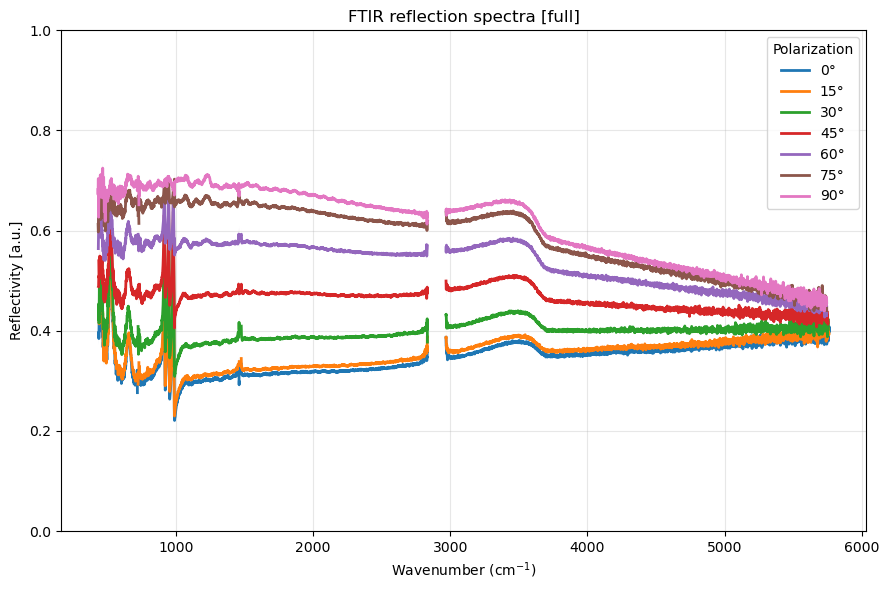

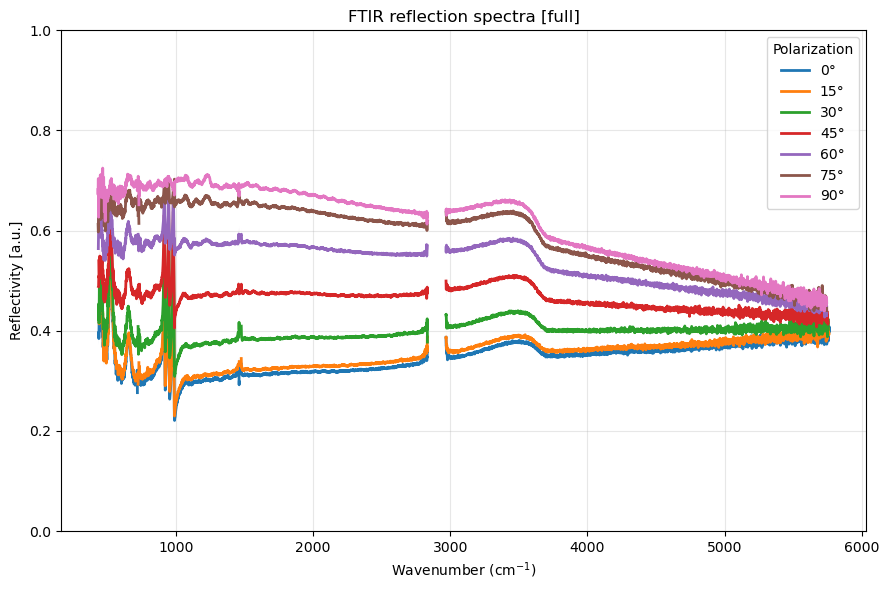

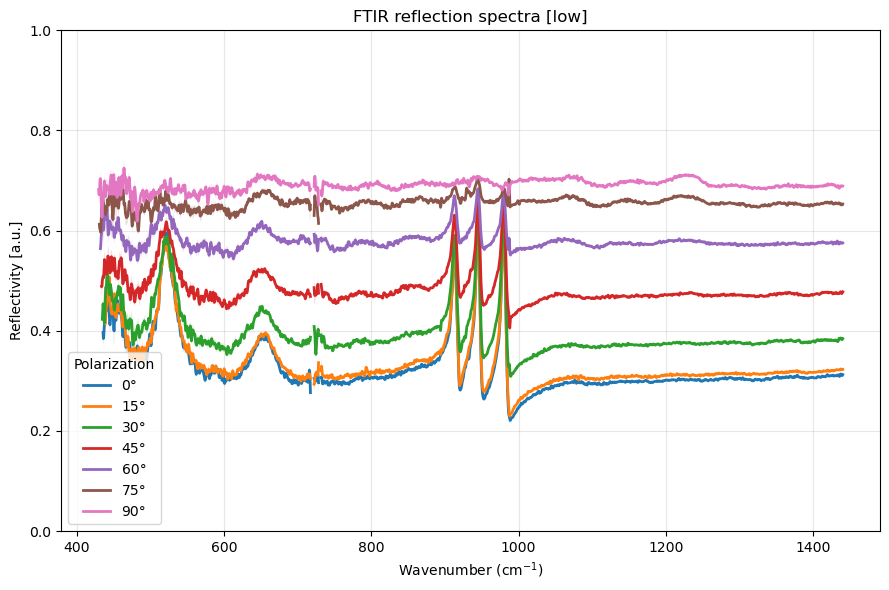

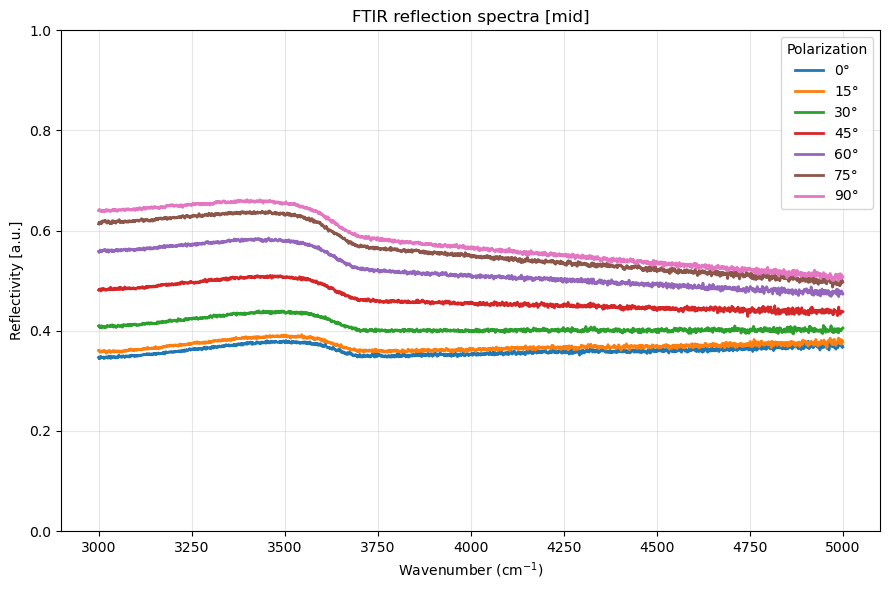

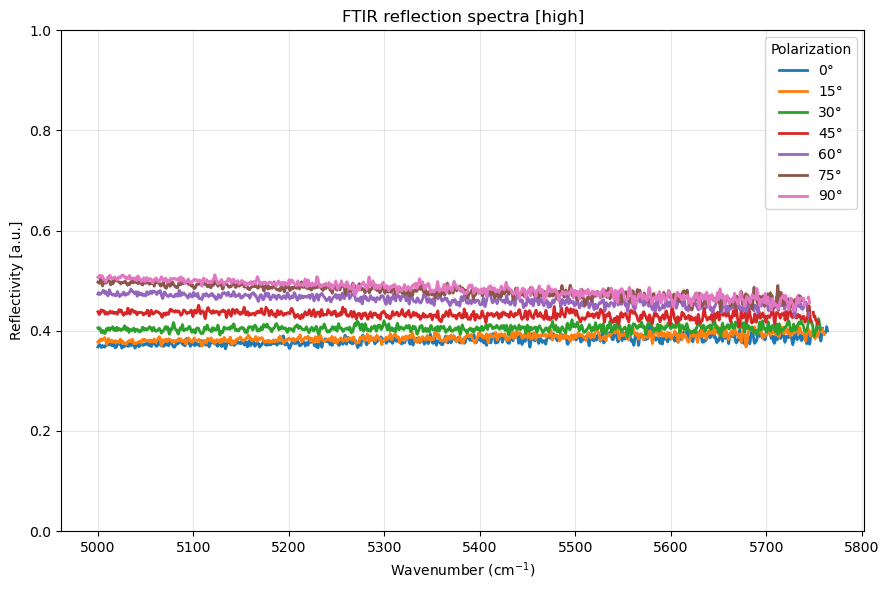

C:\Users\dsapa\AppData\Local\Temp\ipykernel_11304\2442815861.py:622: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


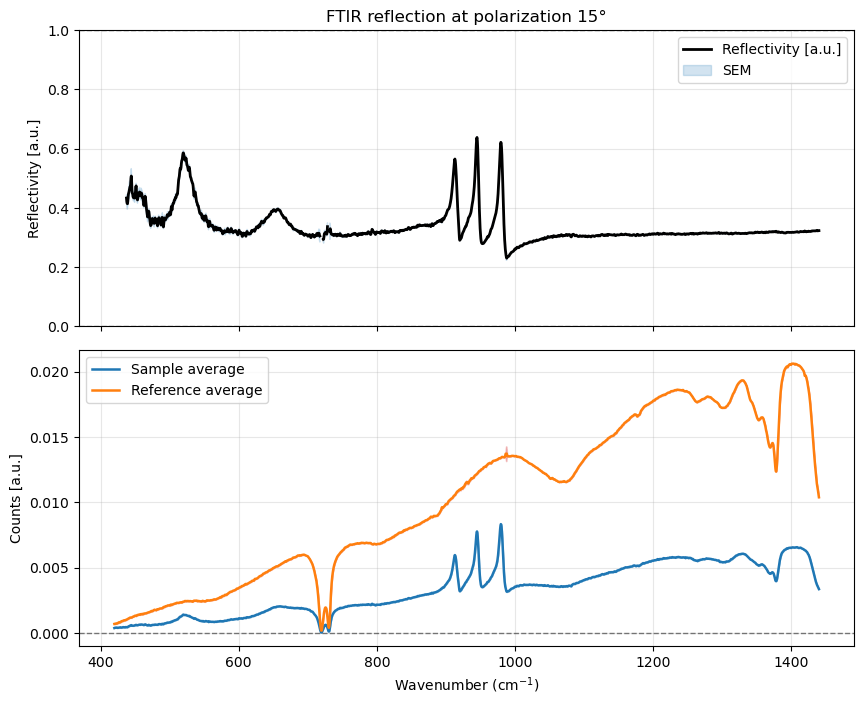

Saved averaged spectra to: C:\Users\dsapa\Desktop\processed_FTIR


In [3]:
"""
USER INTERFACE
--------------
Edit only this cell to define the dataset and plotting options.

measurement_mode options:
- "polarization_loop":
    Polarization-dependent sample/reference measurement.
    Expected filenames:
        SampleName-PolXXdeg-RunX.0
        ReferenceName-PolXXdeg-RunX.0

- "single_measurement":
    One sample spectrum divided by one reference spectrum.
    Expected filenames:
        SampleName.0
        ReferenceName.0

- "single_spectrum":
    One sample spectrum only, without reference normalization.
    Expected filename:
        SampleName.0
"""

ftir = Bruker_FTIR_Data_Processing(
    folder=r"C:\Users\dsapa\Desktop\Extra\FTIR Code\Data_set",
    sample_name="BB1Ms2mmAp1mm",
    reference_name="GoldMirrorMs2mmAp1mm",
    measurement_mode="polarization_loop",   # "polarization_loop", "single_measurement", "single_spectrum"
    spectrum_type="reflection",             # "reflection", "transmission"
    min_reference=1e-3,                     # threshold below which reference values are ignored to avoid division artifacts
    x_windows=[                             # additional spectral ranges to plot when plot_spectrum_windows=True
        ("low", 420, 1440),
        ("mid", 3000, 5000),
        ("high", 5000, 8000),
    ],
    y_limits=(0, 1.0),
)

meta_table, stats, final_table = ftir.process()

ftir.plot()
ftir.plot(plot_spectrum_windows=True)
if ftir.measurement_mode == "polarization_loop":
    ftir.plot(pol_angle=15, x_limits=(420, 1440))
ftir.save_averaged_spectra(
    output_folder=r"C:\Users\dsapa\Desktop\processed_FTIR"
)